In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import joblib
import warnings
import time
warnings.filterwarnings("ignore")

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.linear_model import Ridge

In [3]:
df_train_production = pd.read_csv('df_train_production.csv')

In [4]:
df_train_production.drop(columns = ['row_id'], inplace = True)
df_train_production.shape

(1004424, 131)

In [5]:
df_train_production.dropna(inplace=True)

In [6]:
df_train_production['unit_target'] = df_train_production['target']/df_train_production['installed_capacity']
df_train_production['unit_target_48h'] = df_train_production['target_48h']/df_train_production['installed_capacity_48h']

In [7]:
df_train_production.dropna(inplace=True)

In [8]:
df_train_production.drop(columns=['year', 'is_consumption', 'day', 'installed_capacity', 'prediction_unit_id', 'target', 'eic_count'], inplace=True)

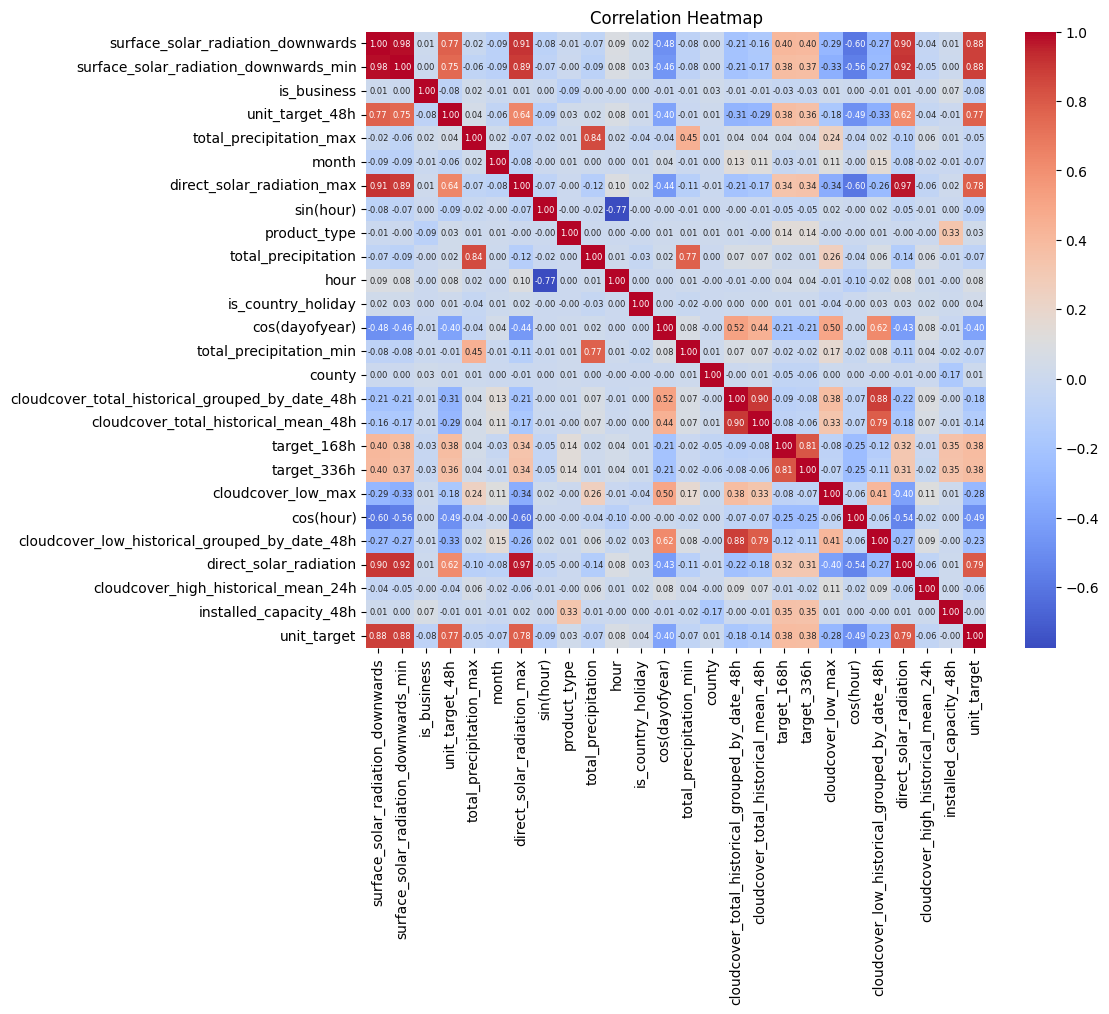

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

df_sns = df_train_production[['surface_solar_radiation_downwards', 'surface_solar_radiation_downwards_min', 'is_business', 'unit_target_48h', 'total_precipitation_max', 
                              'month', 'direct_solar_radiation_max', 'sin(hour)', 'product_type', 'total_precipitation', 'hour', 'is_country_holiday', 'cos(dayofyear)', 
                              'total_precipitation_min', 'county', 'cloudcover_total_historical_grouped_by_date_48h', 'cloudcover_total_historical_mean_48h', 'target_168h', 'target_336h', 
                              'cloudcover_low_max', 'cos(hour)', 'cloudcover_low_historical_grouped_by_date_48h', 'direct_solar_radiation', 
                              'cloudcover_high_historical_mean_24h', 'installed_capacity_48h', 'unit_target']]

scaler = StandardScaler()
scaled_df = scaler.fit_transform(df_sns)

scaled_df = pd.DataFrame(scaled_df, columns=df_sns.columns)

corr = scaled_df.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={'size': 6})
plt.title('Correlation Heatmap')
plt.show()

In [10]:
X_prod = df_train_production.drop(columns=['unit_target', 'datetime'])
y_prod = df_train_production[['unit_target', 'datetime']]

split_index = int(0.6 * len(X_prod))

X_train_prod, X_test_prod = X_prod[:split_index], X_prod[split_index:]
y_train_prod, y_test_prod = y_prod[:split_index], y_prod[split_index:]

In [11]:
top_features = ['surface_solar_radiation_downwards', 'surface_solar_radiation_downwards_min', 'is_business', 'unit_target_48h', 'total_precipitation_max', 'month', 'direct_solar_radiation_max', 'sin(hour)', 'product_type', 'total_precipitation', 'hour', 'is_country_holiday', 'cos(dayofyear)', 'total_precipitation_min', 'county', 'cloudcover_total_historical_grouped_by_date_48h', 'cloudcover_total_historical_mean_48h', 'target_168h', 'target_336h', 'cloudcover_low_max', 'cos(hour)', 'cloudcover_low_historical_grouped_by_date_48h', 'direct_solar_radiation', 'cloudcover_high_historical_mean_24h', 'installed_capacity_48h']
#Selecting the top N features from the dataset
X_train_prod_reduced = X_train_prod[top_features]
X_test_prod_reduced = X_test_prod[top_features]

In [12]:
len(top_features)

25

Ridge

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_prod_reduced)
X_test_scaled = scaler.transform(X_test_prod_reduced)

In [14]:
# Ridge Regression
print('Training Ridge:')
ridge_model = Ridge(alpha=28)  

# Training the model
start_time_tr = time.time()
ridge_model.fit(X_train_scaled, y_train_prod['unit_target'])
end_time_tr = time.time()

# Making predictions
start_time_pr = time.time()
ridge_pred = ridge_model.predict(X_test_scaled)
end_time_pr = time.time()

# Calculate training and prediction time
training_time = end_time_tr - start_time_tr
prediction_time = end_time_pr - start_time_pr

# Calculate metrics
mae = mean_absolute_error(y_test_prod['unit_target'], ridge_pred)
r2 = r2_score(y_test_prod['unit_target'], ridge_pred)
rmse = root_mean_squared_error(y_test_prod['unit_target'], ridge_pred)
mse = mean_squared_error(y_test_prod['unit_target'], ridge_pred)

# Create a dictionary to store the results
results = {
    'Model': ['Ridge'],
    'Training Time (s)': [training_time],
    'Prediction Time (s)': [prediction_time],
    'MAE': [mae],
    'R-squared': [r2],
    'RMSE': [rmse],
    'MSE': [mse]
}

# Convert the dictionary to a DataFrame
results_df = pd.DataFrame(results)

# Save the results to a CSV file
results_df.to_csv('ridge_metrics.csv', index=False)

# Save the model using joblib
joblib.dump(ridge_model, 'ridge_model.joblib')

print("Metrics saved to 'ridge_metrics.csv'")
print("Model saved as 'ridge_model.joblib'")
print(f"Training time: {training_time:.4f} seconds")
print(f"Prediction time: {prediction_time:.4f} seconds")

Training Ridge:
Metrics saved to 'ridge_metrics.csv'
Model saved as 'ridge_model.joblib'
Training time: 0.0581 seconds
Prediction time: 0.0054 seconds
